Robust Scaling is used because it is robust to outliers. So This performs better when there are a lot of outliers. 

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])
df.columns=['Class label', 'Alcohol', 'Malic acid']

In [3]:
df

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

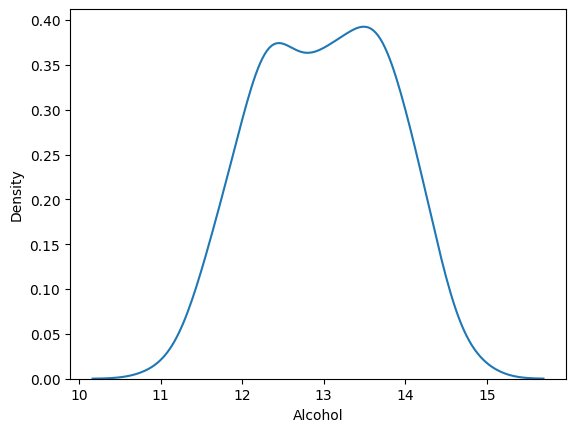

In [4]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

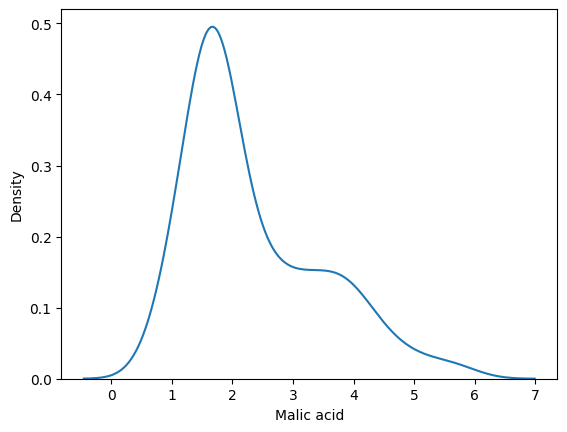

In [5]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

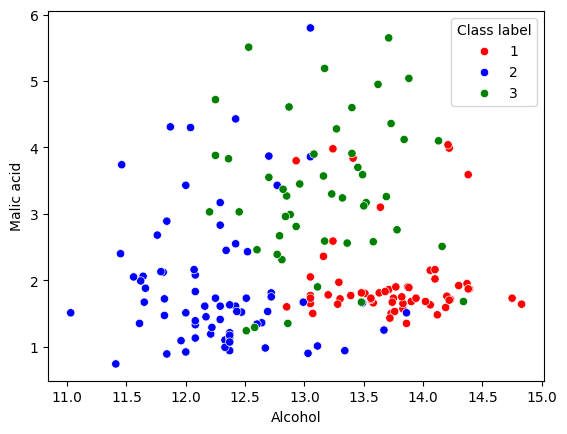

In [6]:
color_dict={1:'red',3:'green',2:'blue'}
sns.scatterplot(data=df,x='Alcohol',y='Malic acid',hue=df['Class label'],palette=color_dict)

In [7]:
df.describe()

,Class label,Alcohol,Malic acid
count,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348
std,0.775035,0.811827,1.117146
min,1.000000,11.030000,0.740000
25%,1.000000,12.362500,1.602500
50%,2.000000,13.050000,1.865000
75%,3.000000,13.677500,3.082500
max,3.000000,14.830000,5.800000


### Adding outliers too see the robust scaling

In [8]:
df = pd.concat([df, pd.DataFrame({'Class label':[2,3,1],'Alcohol':[5.0432,23.2342,18.454234],'Malic acid':[0.0134,10.43523,13.34534]})],ignore_index=True)
# 'Class label', 'Alcohol', 'Malic acid']


In [9]:
df.describe()


,Class label,Alcohol,Malic acid
count,181.000000,181.000000,181.000000
mean,1.939227,13.043324,2.429083
std,0.775785,1.321011,1.512041
min,1.000000,5.043200,0.013400
25%,1.000000,12.360000,1.600000
50%,2.000000,13.050000,1.870000
75%,3.000000,13.690000,3.120000
max,3.000000,23.234200,13.345340


<Axes: xlabel='Alcohol', ylabel='Malic acid'>

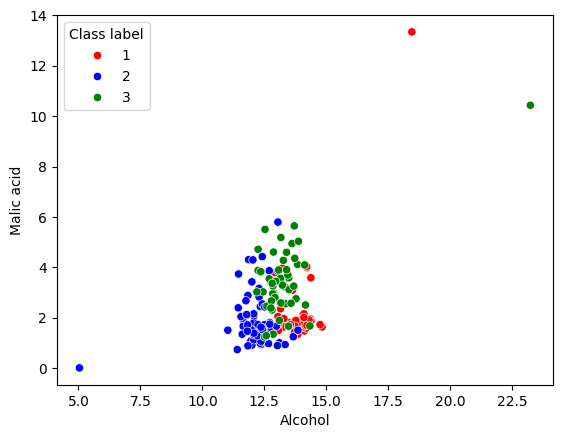

In [10]:
color_dict={1:'red',3:'green',2:'blue'}
sns.scatterplot(data=df,x='Alcohol',y='Malic acid',hue=df['Class label'],palette=color_dict)

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class label', axis=1),
                                                    df['Class label'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((126, 2), (55, 2))

In [12]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [14]:
np.round(X_train.describe(), 1)

,Alcohol,Malic acid
count,126.0,126.0
mean,13.1,2.5
std,1.3,1.6
min,11.0,0.7
25%,12.3,1.6
50%,13.0,1.9
75%,13.7,3.0
max,23.2,13.3


In [15]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic acid
count,126.0,126.0
mean,0.1,0.4
std,1.0,1.2
min,-1.5,-0.8
25%,-0.5,-0.2
50%,0.0,-0.0
75%,0.5,0.8
max,7.7,8.1


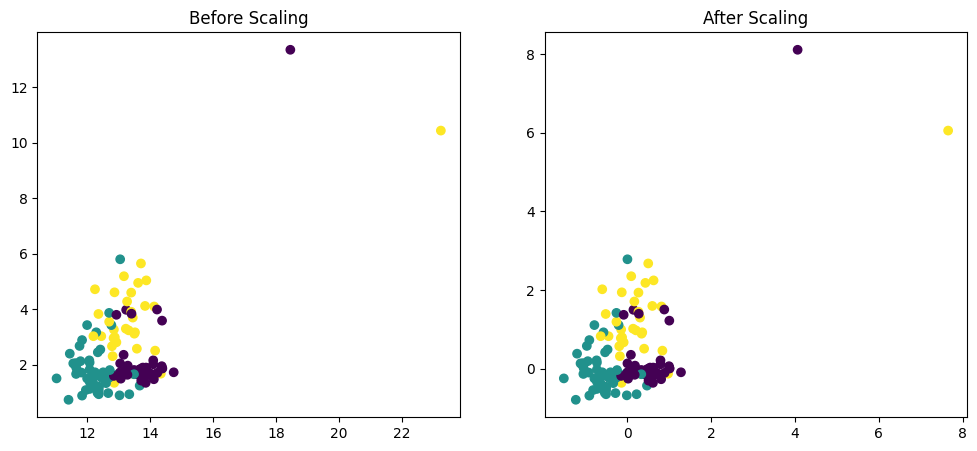

In [16]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Alcohol'], X_train['Malic acid'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

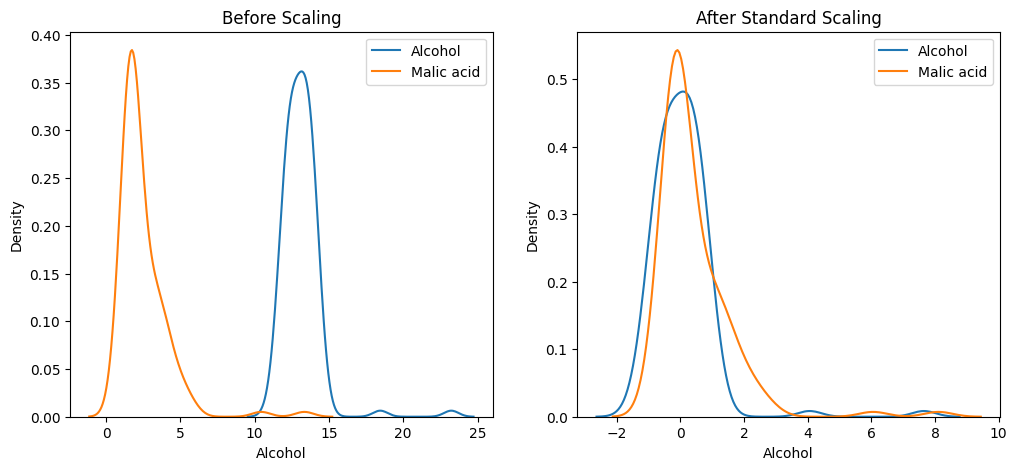

In [17]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1, label='Alcohol')
sns.kdeplot(X_train['Malic acid'], ax=ax1, label='Malic acid')
ax1.legend()

# After scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2, label='Alcohol')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2, label='Malic acid')
ax2.legend()

plt.show()

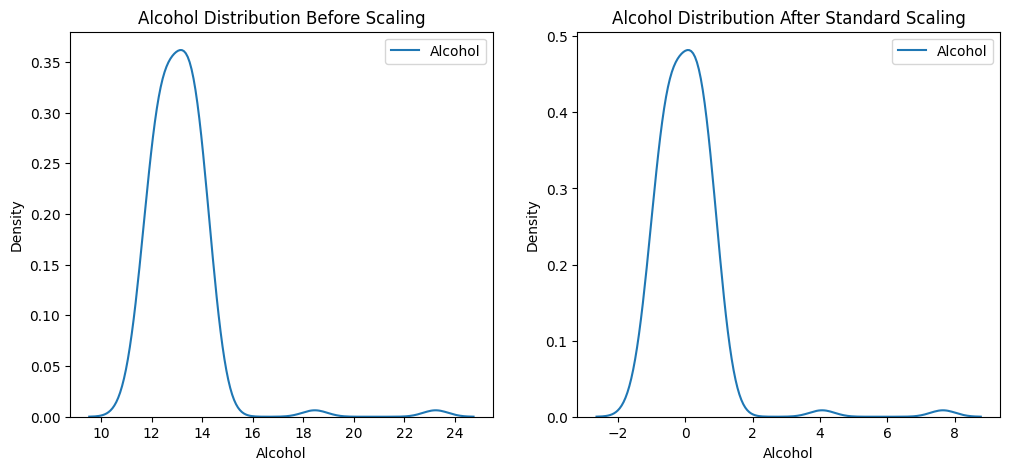

In [18]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1 , label="Alcohol")
ax1.legend()

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2, label="Alcohol")
ax2.legend()

plt.show()

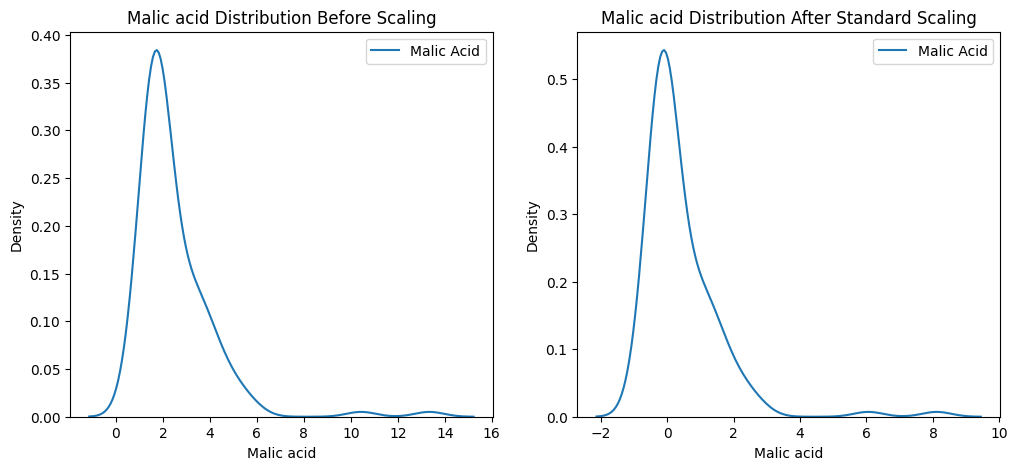

In [19]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic acid'], ax=ax1,label="Malic Acid")
ax1.legend()

# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2, label="Malic Acid")
ax2.legend()

plt.show()